# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

Looking in indexes: https://repo.forge.lmig.com/api/pypi/python/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 3.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.2/25.2 MB 4.9 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.
[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

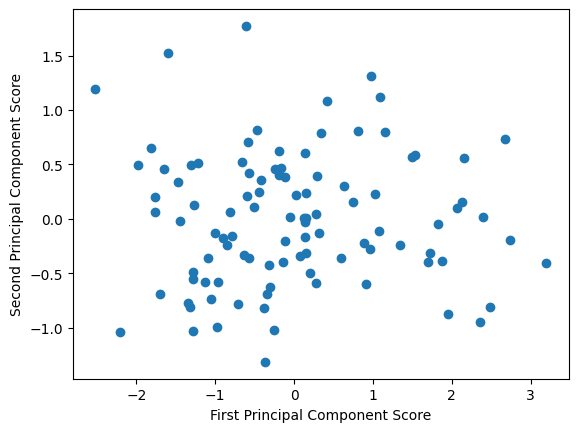

In [ ]:


import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

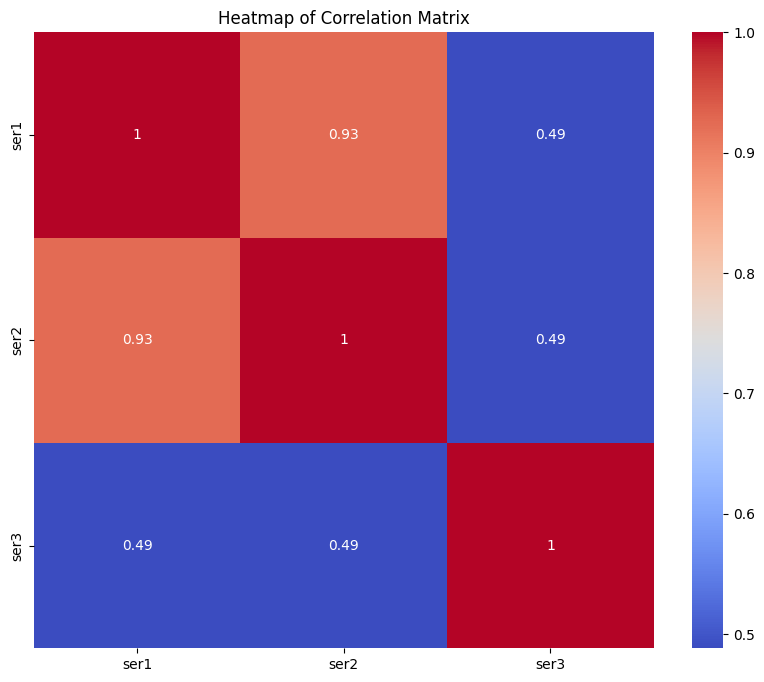

In [ ]:

import seaborn as sns

# Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Heatmap of Correlation Matrix')
plt.show()


/Users/n1528741/Library/CloudStorage/OneDrive-LibertyMutual/Desktop/2025-spring-B2/.venv/lib/python3.13/site-packages/matplotlib/collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


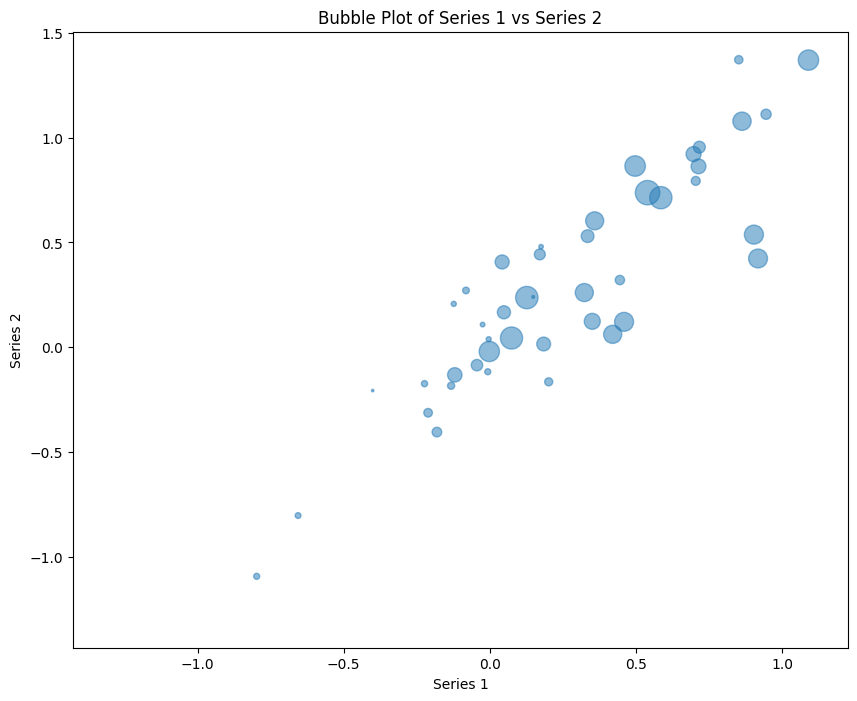

In [ ]:

# Bubble plot
plt.figure(figsize=(10, 8))
plt.scatter(df['ser1'], df['ser2'], s=df['ser3']*100, alpha=0.5)
plt.xlabel('Series 1')
plt.ylabel('Series 2')
plt.title('Bubble Plot of Series 1 vs Series 2')
plt.show()


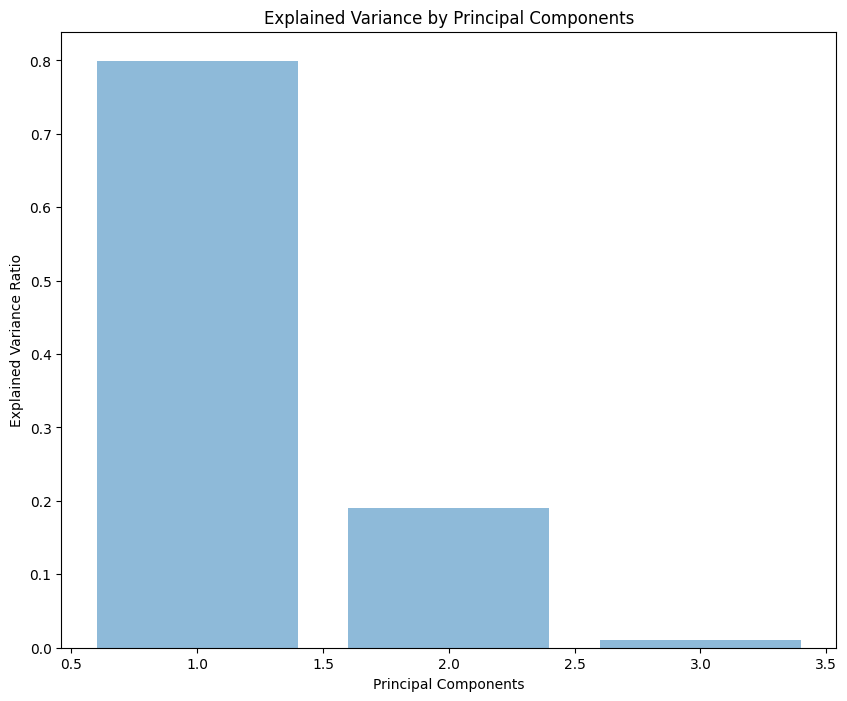

In [ ]:

# Plot explained variance
plt.figure(figsize=(10, 8))
plt.bar(range(1, 4), pca3.explained_variance_ratio_, alpha=0.5, align='center')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Principal Components')
plt.show()


In [ ]:

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Features and target
X = df[['ser1', 'ser2']]
y = df['ser3']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

Data Expectations: Compare your findings with your initial hypotheses. Are the patterns and relationships what you expected?
Usability: Assess if the data quality and structure are suitable for your analyses. If not, consider finding new datasets.
Outliers: Identify any data points that deviate significantly from the rest. Use visualization tools like scatter plots or box plots.
Dimensionality Reduction: Evaluate if PCA suggests a way to represent the data using fewer dimensions. This can simplify your analysis and improve model performance.
Feature Selection: Use correlation information to select features that are most predictive for linear regression.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

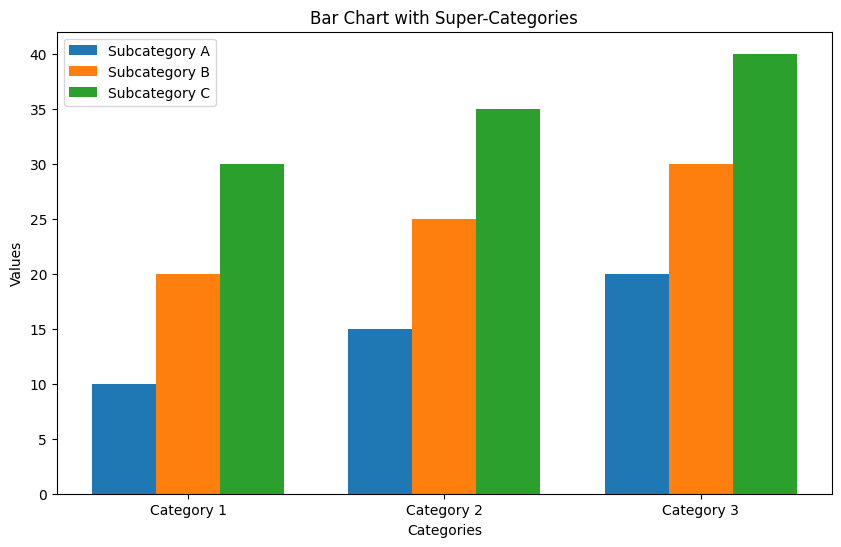

In [ ]:

import numpy as np

# Example data
categories = ['Category 1', 'Category 2', 'Category 3']
subcategories = ['Subcategory A', 'Subcategory B', 'Subcategory C']
values = np.array([[10, 20, 30], [15, 25, 35], [20, 30, 40]])

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.25
index = np.arange(len(categories))

for i, subcategory in enumerate(subcategories):
    ax.bar(index + i * bar_width, values[:, i], bar_width, label=subcategory)

# Adding labels and title
ax.set_xlabel('Categories')
ax.set_ylabel('Values')
ax.set_title('Bar Chart with Super-Categories')
ax.set_xticks(index + bar_width)
ax.set_xticklabels(categories)
ax.legend()

